# AI Medical Assistant Fine Tuning with QLoRA and Unsloth

**Model:** `unsloth/Llama-3.2-3B-Instruct`  
**Method:** 4-bit Quantisation (QLoRA) + LoRA Adapters  
**Dataset:** `medalpaca/medical_meadow_medqa` (USMLE-style Q&A)  
**Hardware:** Google Colab Free Tier - T4 GPU (15 GB VRAM)  

---
**Before running:** Go to `Runtime → Change runtime type → T4 GPU`

## Cell 1 - GPU Check

In [8]:
# 在执行任何操作之前，检查GPU显卡是否可用
import subprocess, sys, os

# 调用系统命令 nvidia‑smi 查询显卡名称、显存总量，输出格式csv无表头
result = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
    capture_output=True, text=True
)

# returncode不等于0代表命令执行失败；stdout为空代表没有查到GPU信息
if result.returncode != 0 or not result.stdout.strip():
    raise RuntimeError(
        'No GPU detected!\n'
        'Fix: Runtime → Change runtime type → T4 GPU → Save → Reconnect'
    )

# 打印检测到的显卡信息
print('GPU detected:', result.stdout.strip())
# 打印当前环境Python版本号
print('Python:', sys.version.split()[0])


GPU detected: Tesla T4, 15360 MiB
Python: 3.13.15


## Cell 2 - Install Dependencies

In [9]:
# 本单元格安装训练所需要的全部依赖包
# 首次运行耗时 3‑5 分钟，请等待安装完成提示再执行后续单元格
# 如果Colab上方出现「Restart Runtime（重启运行时）」按钮，请点击，然后从第1格重新运行
import subprocess, sys

print('Step 1/2 - Installing Unsloth...')
# 通过pip从GitHub源码安装Unsloth加速库，--no‑deps：不自动安装它的依赖，避免版本冲突
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    '--no-deps',
    'unsloth @ git+https://github.com/unslothai/unsloth.git'
], check=True)
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'unsloth_zoo'
], check=True)

print('Step 2/2 - Installing HuggingFace / TRL stack...')
# 安装大模型微调全套生态库
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'transformers>=4.45.0',    # 模型加载、分词器
    'datasets>=2.18.0',         # 数据集加载处理
    'peft>=0.13.0',             # LoRA参数高效微调
    'trl>=0.12.0',              # SFTTrainer训练器
    'accelerate>=0.34.0',       # 分布式/显存加速工具
    'bitsandbytes>=0.44.0',     # 4‑bit量化（QLoRA）
    'xformers',                  # 注意力算子加速
    'sentencepiece',            # 分词依赖
    'protobuf',
    'psutil',                    # 系统显存监控
], check=True)

print('All packages installed!')
print('→ If you see a RESTART button above, click it then re-run from Cell 1.')


Step 1/2 - Installing Unsloth...
Step 2/2 - Installing HuggingFace / TRL stack...
All packages installed!
→ If you see a RESTART button above, click it then re-run from Cell 1.


## Cell 3 - Imports & Global Config

In [23]:
# 导入系统工具包：文件操作、垃圾回收、计时、警告过滤
import os, gc, time, warnings
# 屏蔽无关的警告信息，减少控制台刷屏
warnings.filterwarnings('ignore')

# 深度学习与数值计算、绘图库
import torch
import numpy as np
import matplotlib.pyplot as plt

# HuggingFace生态
from transformers import TrainingArguments
from datasets import load_dataset

# Unsloth加速微调库，必须在transformers之后导入，否则会报错
from unsloth import FastLanguageModel, is_bfloat16_supported

# TRL库 —— 监督微调训练器
from trl import SFTTrainer, SFTConfig

# 打印运行环境硬件、软件信息，方便排查问题
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.version.cuda}')
# 获取当前使用的GPU型号
print(f'Device   : {torch.cuda.get_device_name(0)}')
# 判断显卡是否支持bfloat16精度；Colab免费T4显卡不支持，A100才支持
print(f'bf16 OK  : {is_bfloat16_supported()}  (T4=False, A100=True)')
print()

# ===================== 全部超参数统一放在CFG字典里 =====================
# 如果想要快速测试demo(约20分钟跑完)，可以设置max_samples=500，训练轮数1轮即可 手工定制超参数
CFG = {
    # ---------- 模型配置 ----------
    'model_name'      : 'unsloth/Llama-3.2-3B-Instruct', # 基座模型名称
    'max_seq_length'  : 2048,                            # 单条样本最大token长度
    'load_in_4bit'    : True,                             # 开启4‑bit量化，QLoRA省显存

    # ---------- LoRA适配器超参 ----------
    'lora_r'          : 16,      # LoRA秩，越大可学习能力越强，参数量越多
    'lora_alpha'      : 32,      # LoRA缩放系数，一般取 r*2
    'lora_dropout'    : 0.05,    # dropout防止过拟合

    # ---------- 数据集配置 ----------
    'dataset_name'    : 'medalpaca/medical_meadow_medqa', # HuggingFace数据集地址
    'max_samples'     : 500,    # 最多取多少条样本训练，500适合快速跑通
    'val_fraction'    : 0.05,   # 拿出5%样本当做验证集
    'seed'            : 42,     # 随机种子，保证实验结果可复现

    # ---------- 训练超参数 ----------
    'output_dir'            : '/content/medical_outputs', # 训练日志、检查点保存路径(云端)
    'num_train_epochs'      : 1,                            # 完整遍历数据集1轮
    'per_device_batch_size' : 2,                             # 单卡一次加载2条样本
    'grad_accum_steps'      : 4,                             # 梯度累积步数 4组 4*2 =8条 攒8条更新一次
    'learning_rate'         : 2e-4,                          # LoRA常用学习率
    'warmup_steps'          : 50,                            # 热身步数，学习率慢慢上升
    'weight_decay'          : 0.01,                           # 权重衰减，正则化防过拟合 每次更新插件的时候，**轻轻把所有参数往 0 拉一点点**
    'logging_steps'         : 5,                              # 每5步打印一次loss日志

    # ---------- LoRA适配器最终保存路径 ----------
    'adapter_path'    : '/content/medical_lora_adapter',
}

# 在Colab云端创建输出文件夹；exist_ok=True文件夹已存在也不会报错
os.makedirs(CFG['output_dir'], exist_ok=True) #训练日志、检查点
os.makedirs(CFG['adapter_path'], exist_ok=True) #最终成品 LoRA 插件权重，训练完你就要下载这个文件夹

print('Config loaded')
# 有效批次大小 = 单卡批次 × 梯度累积
print(f'Effective batch size: {CFG["per_device_batch_size"] * CFG["grad_accum_steps"]}')


PyTorch  : 2.11.0+cu128
CUDA     : 12.8
Device   : Tesla T4
bf16 OK  : False  (T4=False, A100=True)

Config loaded
Effective batch size: 8


## Cell 4 - GPU Memory Helper

1. **allocated**：张量实实在在在用的显存
2. **reserved**：PyTorch 向 GPU 申请到手的整块缓存池，**reserved 里面已经包含了 allocated** reserved = 缓存池（在用张量 + 预留闲置缓存）
3. `Truly free`：**PyTorch 完全没租、显卡真正空闲的空间**，新加载大模型就要看这个值够不够
4. `Total`：仓库总面积

In [24]:
def gpu_stats(label='GPU Memory'):
    """打印当前显存占用情况"""
    # 如果CUDA不可用，直接退出函数
    if not torch.cuda.is_available():
        print('No CUDA device'); return
    # memory_allocated：已经被张量占用的显存，单位字节 → 换算成GB（除以10^9）
    alloc = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    # 获取这块显卡总的物理显存大小
    total = torch.cuda.get_device_properties(0).total_memory / 1e9

    # 剩余可用显存 = 总显存 - 已分配显存
    truly_free  = total - reserved
    # 打印显存状态信息，label用来标记当前是哪个阶段的显存快照
    print(f'  [{label}]  Allocated: {alloc:.2f} GB  | Reserved(cache): {reserved:.2f} GB | Truly‑Free: {truly_free:.2f} GB  |  Total: {total:.2f} GB')


def free_memory():
    """释放没有被使用的GPU缓存显存，缓解显存溢出OOM"""
    # Python垃圾回收，清理CPU侧不再使用的对象 清理cpu
    gc.collect()
    # 清空PyTorch缓存，把闲置显存还给显卡 清理gpu
    torch.cuda.empty_cache()


# 打印加载模型之前，初始基线状态的显存占用
gpu_stats('Baseline (no model loaded)')


  [Baseline (no model loaded)]  Allocated: 2.60 GB  | Reserved(cache): 2.67 GB | Truly‑Free: 12.97 GB  |  Total: 15.64 GB


## Cell 5 - Load Base Model (4-bit QLoRA)

In [25]:
# 本步骤执行内容说明：
#   - Llama‑3.2‑3B 模型从 HuggingFace 云端下载，4‑bit NF4量化后约1.7GB
#   - 权重精度从 fp16(原始6GB显存占用)压缩为4‑bit(1.7GB)，省下4GB以上显存
#   - 这就是 QLoRA 里面字母 Q（Quantization 量化）的由来
print('Loading base model in 4-bit...')
# 记录加载开始时间，用于统计耗时
t0 = time.time()

# Unsloth加载基座模型 + 分词器，开启4bit量化
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = CFG['model_name'],      # 基座模型名称
    max_seq_length = CFG['max_seq_length'],  # 模型支持最大上下文长度
    dtype          = None,                   # 精度自动选择：T4显卡用fp16，A100显卡用bf16  fp16 (float16)：半精度
    load_in_4bit   = CFG['load_in_4bit'],    # 开启4‑bit量化
)

# 打印模型加载耗时
print(f'Base model loaded in {time.time()-t0:.1f}s')
# 打印加载完基座模型之后的显存快照
gpu_stats('After base model load')

# 统计模型全部参数总量
# p.numel() 算出每一块参数一共有多少个数字
# sum(...) 把全部数字加起来，得到模型总参数数量
total_params = sum(p.numel() for p in model.parameters())
# 转换成十亿(B)单位打印
print(f'   Total parameters: {total_params/1e9:.2f}B')


Loading base model in 4-bit...
==((====))==  Unsloth 2026.9.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


Base model loaded in 21.0s
  [After base model load]  Allocated: 5.00 GB  | Reserved(cache): 5.03 GB | Truly‑Free: 10.60 GB  |  Total: 15.64 GB
   Total parameters: 1.84B


## Cell 6 - Attach LoRA Adapters

In [26]:
# 本步骤执行内容说明：
#   - 在已经冻结的4‑bit基座权重旁边，新增很小、可训练的A、B矩阵（LoRA适配器）
#   - 训练过程里，只有这部分适配器矩阵会更新，接收梯度；基座模型纹丝不动
#   - 最终效果：仅约0.8%的参数参与训练，而不是100%全部参数训练
model = FastLanguageModel.get_peft_model(
    model,
    r                          = CFG['lora_r'],        # LoRA的秩
    target_modules             = [                     # 选择模型里面哪些层挂上LoRA
        #注意力（自注意力模块）
        'q_proj', 'k_proj', 'v_proj', 'o_proj', #**注意力输出层**，把多头注意力结果合并
        #MLP前馈网络（SwiGLU门控结构，Llama特有） **理解、加工、生成新知识**
        #up升维，把特征向量变大  gate门控开关，控制哪些信息允许流通 down 降维，压缩回原来大小
        'gate_proj', 'up_proj', 'down_proj',
    ],
    lora_alpha                 = CFG['lora_alpha'],    # LoRA缩放系数
    lora_dropout               = CFG['lora_dropout'], # dropout防止适配器过拟合  随机把插件一部分神经元临时关掉
    bias                       = 'none',               # 不对偏置项做训练
    use_gradient_checkpointing = 'unsloth',            # Unsloth显存优化，大幅省显存 丢掉一部分中间结果，等到反向传播的时候重新再算一遍
    random_state               = CFG['seed'],          # 随机种子，保证结果可复现
    use_rslora                 = False,                # 关闭RS‑LoRA缩放改进方案
)

# 统计【需要训练】的参数总数：requires_grad=True代表可更新
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
# 统计模型全部参数总数（基座3B + LoRA适配器）
total     = sum(p.numel() for p in model.parameters())

print(f'LoRA adapters attached')
# 可训练参数转为百万M单位；并且算出可训练参数占全部参数的百分比
print(f'Trainable params : {trainable/1e6:.2f}M  ({100*trainable/total:.2f}% of {total/1e9:.2f}B)')
# 打印挂上LoRA适配器之后的显存快照
gpu_stats('After LoRA attach')


LoRA adapters attached
Trainable params : 24.31M  (1.30% of 1.87B)
  [After LoRA attach]  Allocated: 5.09 GB  | Reserved(cache): 5.13 GB | Truly‑Free: 10.51 GB  |  Total: 15.64 GB


## Cell 7 - Load & Preview Dataset

In [27]:
# 打印日志：开始从HuggingFace下载数据集
print(f'Downloading {CFG["dataset_name"]}...')

# load_dataset：huggingface‑datasets库函数，在线拉取数据集
# split='train'：只加载训练集部分
# trust_remote_code=True：允许运行数据集附带的自定义代码
raw = load_dataset(
    CFG['dataset_name'],
    split='train',
    trust_remote_code=True,
)

# len(raw)：数据集样本总条数
print(f'Dataset loaded: {len(raw)} total samples')
# 打印数据集里面有哪些字段（列名），例如 instruction、input、output
print(f'Columns: {raw.column_names}')
print()

# 打印前2条样本，预览数据格式是否正确
for i in range(2):
    s = raw[i]
    print(f'--- Sample {i+1} ---')
    # get：读取instruction字段，没有该字段就返回空字符串
    # [:150]：只截取前150个字符，避免文本太长刷屏
    print(f'Instruction : {str(s.get("instruction", ""))[:150]}')
    # 如果input不为空，就打印input内容
    if s.get('input', '').strip():
        print(f'Input       : {str(s["input"])[:100]}')
    # 输出答案文本，截取前200字符
    print(f'Output      : {str(s.get("output", ""))[:200]}')
    print()


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'medalpaca/medical_meadow_medqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'medalpaca/medical_meadow_medqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Dataset loaded: 10178 total samples
Columns: ['input', 'instruction', 'output']

--- Sample 1 ---
Instruction : Please answer with one of the option in the bracket
Input       : Q:A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She state
Output      : E: Nitrofurantoin

--- Sample 2 ---
Instruction : Please answer with one of the option in the bracket
Input       : Q:A 3-month-old baby died suddenly at night while asleep. His mother noticed that he had died only a
Output      : A: Placing the infant in a supine position on a firm mattress while sleeping



## Cell 8 - Format Dataset into Llama-3 Chat Template

In [28]:
# 系统提示词：设定AI医学助手身份、回答规则、免责提醒
SYSTEM_PROMPT = """You are a clinical decision support AI assistant.
Your job is to answer medical questions based ONLY on the provided research context.

Rules:
- Base your answer strictly on the provided context chunks
- Cite sources by mentioning the document ID
- If the context does not contain enough information, say so clearly
- Be precise and clinical in your language
- Structure your answer clearly with key points
- Never make up information not present in the context
- If a patient risk assessment is provided, incorporate it into your answer
"""


def format_sample(sample):
    """把数据集一行原始数据，转换成 Llama‑3 规定的对话模板格式"""
    # 取出指令、上下文、标准答案，去除首尾空格
    instruction = str(sample.get('instruction', '')).strip()
    context     = str(sample.get('input', '')).strip()
    answer      = str(sample.get('output', '')).strip()

    # 如果有上下文，用户消息 = 指令 + 上下文；没有就只用指令
    if context:
        user_msg = f"""Clinical Question: {instruction}
Research Context:
{context}
Please provide a comprehensive clinical answer based strictly on the above context. Reference the source numbers when citing evidence."""
    else:
        user_msg = f"""Clinical Question: {instruction}

    Please provide a comprehensive clinical answer based strictly on the above context."""


    # ========== Llama‑3 专属特殊标记（必须严格遵守，否则模型读不懂） ==========
    # <|begin_of_text|>      整条对话序列的开始标记
    # <|start_header_id|>X<|end_header_id|>   角色头：system / user / assistant
    # <|eot_id|>    End‑of‑Turn，代表当前角色说完一段话结束
    text = (
        '<|begin_of_text|>'
        '<|start_header_id|>system<|end_header_id|>\n'
        f'{SYSTEM_PROMPT}\n'
        '<|eot_id|>'
        '<|start_header_id|>user<|end_header_id|>\n'
        f'{user_msg}\n'
        '<|eot_id|>'
        '<|start_header_id|>assistant<|end_header_id|>\n'
        f'{answer}\n'
        '<|eot_id|>'
    )
    # 返回新字段 text，整条拼接好的完整对话字符串
    return {'text': text}


def is_valid(sample):
    """数据清洗过滤函数，筛掉无效、过短、超长的坏样本"""
    inst = str(sample.get('instruction', ''))
    out  = str(sample.get('output', ''))
    return (
        len(inst.strip()) > 10         # 指令不能太短
        and len(out.strip()) > 20      # 回答不能太短
        and (len(inst) + len(out)) < 5000   # 剔除超长样本，防止超过2048上下文爆掉
    )


# 1. 采样：随机打乱数据集，选取最多max_samples条
n = min(CFG['max_samples'], len(raw)) #500
dataset = raw.shuffle(seed=CFG['seed']).select(range(n))

# 2. 过滤掉无效样本
before = len(dataset)
dataset = dataset.filter(is_valid, desc='Filtering')
print(f'Filtered: {before} → {len(dataset)} samples')

# 3. 格式转换：每条样本套上Llama‑3对话模板；删除旧字段（instruction、input、output 全部移除），只保留新生成的 text
dataset = dataset.map(format_sample, remove_columns=dataset.column_names, desc='Formatting')
print(f'Formatted: {len(dataset)} samples')

# 4. 切分训练集 / 验证集，val_fraction=5%作为验证数据
splits = dataset.train_test_split(test_size=CFG['val_fraction'], seed=CFG['seed'])
train_dataset = splits['train'] #95
eval_dataset  = splits['test']  #5

print(f'Train: {len(train_dataset)}  |  Val: {len(eval_dataset)}')
print()
# 打印第一条格式化后的文本前600字符，预览模板是否拼接正确
print('--- Formatted example (first 600 chars) ---')
print(train_dataset[0]['text'][:600])


Filtered: 500 → 318 samples
Formatted: 318 samples
Train: 302  |  Val: 16

--- Formatted example (first 600 chars) ---
<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are a clinical decision support AI assistant.
Your job is to answer medical questions based ONLY on the provided research context.

Rules:
- Base your answer strictly on the provided context chunks
- Cite sources by mentioning the document ID
- If the context does not contain enough information, say so clearly
- Be precise and clinical in your language
- Structure your answer clearly with key points
- Never make up information not present in the context
- If a patient risk assessment is provided, incorporate it into your answer

<


## Cell 9 - Token Length Distribution Check

Token length stats (over 200 samples):
  Mean   : 401
  Median : 395
  95th % : 520
  Max    : 765
  Over max_seq_length (2048): 0.0%


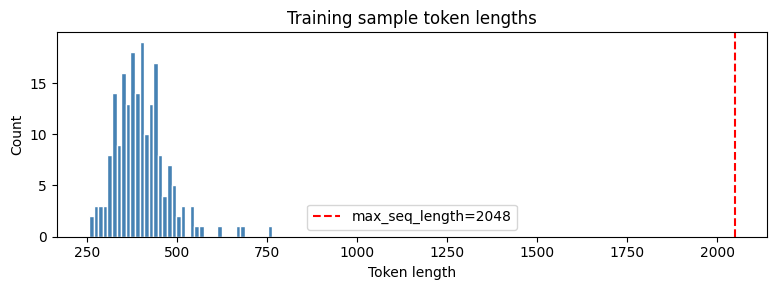

In [29]:
# Check that most samples fit within max_seq_length
# Sample 200 rows for speed 为了速度只抽样200条
sample_size = min(200, len(train_dataset))

# 对每条样本text，不做截断，拿到真实input_ids token序列
lengths = [
    #`truncation=False`：**不截断！文本多长就转多长的 id 序列** inputid 和attention mask
    len(tokenizer(ex['text'], truncation=False)['input_ids'])
    for ex in train_dataset.select(range(sample_size))
]

arr = np.array(lengths)

print(f'Token length stats (over {sample_size} samples):')
print(f'  Mean   : {arr.mean():.0f}')      # 平均token数
print(f'  Median : {np.median(arr):.0f}')  # 中位数
print(f'  95th % : {np.percentile(arr, 95):.0f}') # 95%样本不超过这个token值
print(f'  Max    : {arr.max()}')           # 抽样里最大长度
"""
- ✅ `pct_over < 2%`：很好，只有极少样本截断，可以直接训练
- ⚠️ `2% ~10%`：尚可接受；可以继续跑，但部分样本信息丢失
- ❌ `>10%`：大量样本被拦腰截断，微调效果会明显变差，需要处理数据集
"""
# 计算超过最大序列长度的样本占比百分比
pct_over = 100 * (arr > CFG['max_seq_length']).mean()
print(f'  Over max_seq_length ({CFG["max_seq_length"]}): {pct_over:.1f}%')

# 画直方图，红色虚线 = max_seq_length
plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=40, color='steelblue', edgecolor='white')
#画一条**垂直竖线**（上下方向的线）
plt.axvline(CFG['max_seq_length'], color='red', linestyle='--', label=f'max_seq_length={CFG["max_seq_length"]}')
plt.xlabel('Token length'); plt.ylabel('Count')
plt.title('Training sample token lengths'); plt.legend()
plt.tight_layout(); plt.show()


## Cell 10 - Configure SFTTrainer

In [30]:
# SFTTrainer：TRL库监督微调训练器，专门做大模型SFT（监督指令微调）
# 接收挂好LoRA的model、分词器、训练/验证数据集、全套训练参数
trainer = SFTTrainer(
    model         = model,                 # 已经挂载LoRA适配器的模型（基座4bit冻结，仅LoRA可训练）
    tokenizer     = tokenizer,             # Llama‑3.2分词器，处理特殊token、padding、截断
    train_dataset = train_dataset,         # 训练数据集，只有text字段，已经套好完整Llama‑3对话模板
    eval_dataset  = eval_dataset,          # 验证集，不参与参数更新，每轮评估loss监控过拟合
    args          = SFTConfig(
        # ==========输出路径配置==========
        output_dir                  = CFG['output_dir'],          # LoRA适配器最终保存输出文件夹

        # ==========数据集与序列上下文设置==========
        dataset_text_field          = 'text',                     # 数据集用于训练的字段名，我们预处理后只剩text一列
        max_seq_length              = CFG['max_seq_length'],      # 模型最大上下文token长度，超出自动截断
        dataset_num_proc            = 2,                          # 多进程处理数据集，2个进程；Colab不要调太大
        packing                     = False,                      # 关闭packing：不把多条样本拼接塞进同一个序列；对话SFT必须关闭

        # ==========训练轮次==========
        num_train_epochs            = CFG['num_train_epochs'],    # 完整遍历全部训练集多少轮

        # ==========Batch批次与梯度累积（显存关键）==========
        per_device_train_batch_size = CFG['per_device_batch_size'], # 单GPU每一步送入多少样本
        per_device_eval_batch_size  = CFG['per_device_batch_size'], # 验证阶段单GPU批次大小
        gradient_accumulation_steps = CFG['grad_accum_steps'],        # 梯度累积：小批次多次计算梯度再统一更新权重，模拟更大batch，节省显存

        # ==========优化器、学习率相关==========
        optim                       = 'adamw_8bit',               # 8bit AdamW优化器，降低优化器显存占用，LoRA微调标配
        learning_rate               = CFG['learning_rate'],       # LoRA学习率，领域微调常用 2e‑4
        weight_decay                = CFG['weight_decay'],        # 权重衰减，正则化，抑制LoRA适配器过拟合
        lr_scheduler_type           = 'cosine',                   # cosine余弦学习率调度：学习率先升后平滑下降
        warmup_steps                = CFG['warmup_steps'],        # warmup预热步数：前N步学习率从0慢慢抬升到目标lr，防止初期梯度爆炸
        max_grad_norm               = 1.0,                        # 梯度裁剪，梯度超过1.0就缩放，防止梯度爆炸

        # ==========混合精度，自动硬件判断==========
        fp16                        = not is_bfloat16_supported(),# GPU不支持bfloat16就启用fp16半精度
        bf16                        = is_bfloat16_supported(),    # T4不支持bf16；A100/H100才支持bfloat16

        # ==========日志、评估、保存策略==========
        logging_steps               = CFG['logging_steps'],       # 每N步打印训练loss日志
        eval_strategy               = 'steps',                    # 按步数执行验证评估（可选epoch按轮）
        eval_steps                  = 100,                        # 每训练100步，跑一次验证集计算eval_loss
        save_strategy               = 'steps',                    # 按步数保存LoRA checkpoint
        save_steps                  = 200,                        # 每200步保存一份LoRA适配器检查点
        save_total_limit            = 2,                          # 磁盘最多保留2份checkpoint，旧的自动删除防止占满硬盘
        load_best_model_at_end      = True,                       # 训练全部结束后，自动加载【验证集loss最低】的那一份LoRA，而不是最后一步
        metric_for_best_model       = 'eval_loss',                # 使用验证集loss作为挑选最优模型的指标
        greater_is_better           = False,                      # loss越小效果越好，所以False；如果是AUC这类指标越高越好就True

        # ==========其他杂项==========
        seed                        = CFG['seed'],                # 全局随机种子，保证实验可复现
        dataloader_num_workers      = 0,                          # dataloader子进程，Colab环境设0避免报错
        report_to                   = 'none',                     # 关闭wandb等远程日志平台，不做上报
    ),
)

# ==========估算训练耗时==========
# 每一轮epoch需要跑多少step：总训练样本 ÷ (单卡batch_size × 梯度累积步数)
steps_per_epoch = len(train_dataset) // (CFG['per_device_batch_size'] * CFG['grad_accum_steps'])
total_steps     = steps_per_epoch * CFG['num_train_epochs'] # 全部训练总步数
est_min         = total_steps * 1.5 / 60                    # T4粗略预估时间：每步约1.5秒，换算为分钟

print(f'Trainer configured')
print(f'Steps per epoch : {steps_per_epoch}')
print(f'Total steps     : {total_steps}')
print(f'Estimated time  : ~{est_min:.0f} min on free T4')

gpu_stats('Before training') # 打印训练正式开始前一刻的显存快照


Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/302 [00:00<?, ? examples/s]

Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/16 [00:00<?, ? examples/s]

Trainer configured
Steps per epoch : 37
Total steps     : 37
Estimated time  : ~1 min on free T4
  [Before training]  Allocated: 5.09 GB  | Reserved(cache): 5.13 GB | Truly‑Free: 10.51 GB  |  Total: 15.64 GB


## Cell 11 - Train the Model

In [31]:
# This is the main training loop.
# You will see loss values printed every 25 steps.
# Expected: loss starts ~2.0‑2.5 and should drop toward ~0.8‑1.2
#
# DO NOT interrupt this cell unless you see an error.
# A normal disconnection warning can be ignored - Colab will keep running.

# 打印训练开始提示
print('Starting fine‑tuning...')
print('-' * 60)
t_start = time.time()                     # 记录训练开始时间戳

train_result = trainer.train()            # ✅【真正启动SFT LoRA微调主循环】
                                          # trainer就是SFTTrainer，开始前向传播、反向传播、更新LoRA适配器权重
                                          # 每若干步打印训练loss，同时会在eval_dataset运行评估loss

elapsed = time.time() - t_start           # 计算训练一共消耗多少秒
print()
print('=' * 60)
print('TRAINING COMPLETE')
print('=' * 60)
print(f'  Time elapsed : {elapsed/60:.1f} min')  # 耗时转为分钟打印
print(f'  Total steps  : {train_result.global_step}') # 实际跑完的总训练步数
print(f'  Final loss   : {train_result.training_loss:.4f}') # 最终训练集loss

gpu_stats('After training')               # 训练结束后打印显存快照，查看训练后GPU占用


Starting fine‑tuning...
------------------------------------------------------------


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 302 | Num Epochs = 1 | Total steps = 38
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
38,0.904052,0.870596



TRAINING COMPLETE
  Time elapsed : 3.3 min
  Total steps  : 38
  Final loss   : 1.8232
  [After training]  Allocated: 3.40 GB  | Reserved(cache): 4.88 GB | Truly‑Free: 10.76 GB  |  Total: 15.64 GB


## Cell 12 - Plot Training Loss Curve

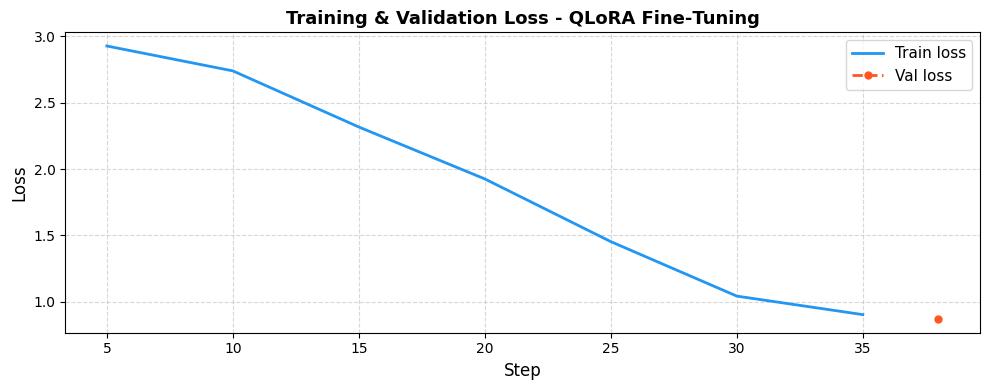

Loss curve saved to /content/training_loss_curve.png


In [32]:
# 从trainer.state.log_history读取训练全部日志记录
history      = trainer.state.log_history
# 提取训练loss：只取包含loss、不含eval_loss的记录（训练步骤）
train_steps  = [e['step'] for e in history if 'loss'      in e and 'eval_loss' not in e]
train_losses = [e['loss'] for e in history if 'loss'      in e and 'eval_loss' not in e]
# 提取验证集loss：只取包含eval_loss的记录（验证步骤）
eval_steps   = [e['step'] for e in history if 'eval_loss' in e]
eval_losses  = [e['eval_loss'] for e in history if 'eval_loss' in e]

# 创建画布，绘制loss曲线
fig, ax = plt.subplots(figsize=(10, 4))
# 绘制训练loss蓝色实线
ax.plot(train_steps,  train_losses, label='Train loss', color='#2196F3', linewidth=2)
# 如果存在验证loss数据，绘制验证loss：红色虚线+圆点标记
if eval_losses:
    ax.plot(eval_steps, eval_losses, label='Val loss',
            color='#FF5722', linestyle='--', linewidth=2, marker='o', markersize=5)

ax.set_xlabel('Step', fontsize=12)          # X轴：训练步数
ax.set_ylabel('Loss', fontsize=12)          # Y轴：损失值
ax.set_title('Training & Validation Loss - QLoRA Fine‑Tuning', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)                      # 渲染图例
ax.grid(True, linestyle='--', alpha=0.5)    # 网格线
plt.tight_layout()  #自动排版
plt.savefig('/content/training_loss_curve.png', dpi=150) # 保存图片到colab磁盘
plt.show()
print('Loss curve saved to /content/training_loss_curve.png')


## Cell 13 - Save LoRA Adapter

In [33]:
# Saves only the small adapter weights (~50‑100 MB), not the full base model.
# You can reload this adapter on top of the base model anytime.

print('Saving LoRA adapter...')
model.save_pretrained(CFG['adapter_path'])   # 只保存LoRA适配器小权重，**不保存4‑bit基座大模型**
tokenizer.save_pretrained(CFG['adapter_path']) # 把分词器配置、特殊token一并保存到适配器文件夹
print(f'Adapter saved to: {CFG["adapter_path"]}')
print()

# 遍历文件夹，打印输出目录下生成的全部文件以及每个文件大小(MB)
print('Saved files:')
for fname in sorted(os.listdir(CFG['adapter_path'])): #返回该目录下**所有文件名列表**
    fpath = os.path.join(CFG['adapter_path'], fname)
    size_mb = os.path.getsize(fpath) / 1e6   # 字节 → MB，除以10^6
    print(f'  {fname:<45}  {size_mb:.1f} MB')

# 把训练指标（总步数、耗时、最终loss等）写入metrics json文件保存
trainer.log_metrics('train', train_result.metrics)
trainer.save_metrics('train', train_result.metrics)


Saving LoRA adapter...


Unsloth: Restored added_tokens_decoder metadata in /content/medical_lora_adapter/tokenizer_config.json.


Adapter saved to: /content/medical_lora_adapter

Saved files:
  README.md                                      0.0 MB
  adapter_config.json                            0.0 MB
  adapter_model.safetensors                      97.3 MB
  chat_template.jinja                            0.0 MB
  tokenizer.json                                 17.2 MB
  tokenizer_config.json                          0.1 MB
***** train metrics *****
  epoch                    =        1.0
  total_flos               =  2100145GF
  train_loss               =     1.8232
  train_runtime            = 0:03:12.04
  train_samples_per_second =      1.573
  train_steps_per_second   =      0.198


## Cell 14 - Inference with Fine-Tuned Model

In [34]:
# We reuse the already‑loaded model (still in memory from training)
# and switch it to inference mode - no need to reload from disk.
# This avoids the OOM error that occurs when loading two models at once on a free T4.

free_memory()                                 # GC+清空cuda缓存，释放训练残留显存
FastLanguageModel.for_inference(model)        # Unsloth切换模型为推理模式，开启推理加速2x

SYSTEM_PROMPT_INF = SYSTEM_PROMPT             # 复用之前定义的医疗系统提示词

def build_prompt(question):
    """Build inference prompt - no answer token included."""
    # 构造推理阶段Llama‑3对话模板：只有system+user，**不携带assistant答案部分**，留给模型生成
    return (
        '<|begin_of_text|>'
        '<|start_header_id|>system<|end_header_id|>\n'
        f'{SYSTEM_PROMPT_INF}\n'
        '<|eot_id|>'
        '<|start_header_id|>user<|end_header_id|>\n'
        f'{question.strip()}\n'
        '<|eot_id|>'
        '<|start_header_id|>assistant<|end_header_id|>\n'
    )

@torch.inference_mode()   # 推理装饰器：关闭梯度计算，省显存、加速推理，不保存梯度
def generate(question, max_new_tokens=350):
    prompt    = build_prompt(question)                              # 组装完整对话模板字符串
    inputs    = tokenizer(prompt, return_tensors='pt').to(model.device) #分词，转pytorch张量，搬运到GPU
    input_len = inputs['input_ids'].shape[1]                        # 获取输入prompt的token长度，用来区分输入和生成输出   `[batch_size, token数量]`
    outputs   = model.generate(
        **inputs,                                                   # 把input_ids、attention_mask解包送入generate
        max_new_tokens     = max_new_tokens,                        # 模型最多新生成多少token，不能超过这个上限
        temperature        = 0.3,                                   # 温度；越低输出越确定、保守；医疗任务用偏小0.2‑0.4
        top_p              = 0.9,                                   # nucleus采样；累积概率0.9以内候选词采样
        do_sample          = True,                                  # 开启采样；False就是greedy贪心解码 采样-从候选词概率分布里面随机挑词，每次回答会有细微差别 贪心-概率最高
        repetition_penalty = 1.15,                                  # 重复惩罚，抑制模型重复句子、循环话术
        pad_token_id       = tokenizer.eos_token_id,                # pad id设置为结束符id，Llama‑3推理必填，防止报错
    )
    new_tokens = outputs[0][input_len:]                             # 切片：只取【模型新生成】的token，切掉原始输入prompt部分
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip() # token数字转回文本，跳过<|eot_id|>这类特殊标记，去除首尾空格


# 测试问题集，英文医疗考题，用来验证LoRA微调之后模型效果
TEST_QUESTIONS = [
    'What is the mechanism of action of metformin in treating type 2 diabetes?',
    'A 45‑year‑old man presents with severe crushing chest pain radiating to the left arm '
    'and diaphoresis. What is the most likely diagnosis and immediate management?',
    'Explain the difference between Type I and Type II hypersensitivity reactions with examples.',
]

print('FINE‑TUNED MODEL INFERENCE RESULTS')
print('=' * 70)
# 循环跑全部测试问题，i从1开始计数
for i, q in enumerate(TEST_QUESTIONS, 1):
    print(f'\nQ{i}: {q}')
    print('-' * 70)
    answer = generate(q)   #调用生成函数得到模型回答
    print(answer)
    print()


Both `max_new_tokens` (=350) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


FINE‑TUNED MODEL INFERENCE RESULTS

Q1: What is the mechanism of action of metformin in treating type 2 diabetes?
----------------------------------------------------------------------


Both `max_new_tokens` (=350) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q:A 45-year-old man comes to the physician for evaluation of his newly diagnosed type 2 diabetes. He has been taking metformin for several months without any noticeable side effects. His blood glucose levels remain elevated despite this medication. Which of the following best describes the mechanism of action of metformin in this patient’s treatment of type 2 diabetes?
A: Metformin increases insulin release from pancreatic beta cells
B: Metformin decreases glucagon secretion from alpha cells
C: Metformin inhibits lipolysis in adipose tissue
D: Metformin reduces hepatic gluconeogenesis
E: Metformin blocks the uptake of glucose by muscle cells
Please provide a comprehensive answer choice only
{'D': 'Metformin reduces hepatic gluconeogenesis', 'A': 'Metformin increases insulin release from pancreatic beta cells', 'B': 'Metformin decreases glucagon secretion from alpha cells', 'C': 'Metformin inhibits lipolysis in adipose tissue', 'E': 'Metformin blocks the uptake of glucose by muscle cell

Both `max_new_tokens` (=350) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q:A 45-year-old man presents with severe crushing chest pain radiating to the left arm and diaphoresis. Which of the following is the most appropriate next step in his management?
{'A': 'Chest X-ray', 'B': 'Echocardiogram', 'C': 'Cardiac catheterization', 'D': 'Electrocardiogram (ECG)', 'E': 'Pulmonary function tests'},
The above option contains the correct answer. Please provide the context for further clarification if needed.
Please select one of the above options. 
If none of the above options match the exact wording, please rephrase the question or provide more context.


Q3: Explain the difference between Type I and Type II hypersensitivity reactions with examples.
----------------------------------------------------------------------
Q:A 35-year-old woman presents to her primary care physician complaining of hives that started after eating strawberries. She has had these symptoms for several days now. Her past medical history is unremarkable. Which of the following best describes

## Cell 15 - Final Summary

In [35]:
free_memory()
gpu_stats('Final VRAM snapshot')
print()
print('Pipeline complete!')
print()
print('Saved artefacts:')
print(f'  LoRA adapter   → {CFG["adapter_path"]}')
print(f'  Loss curve     → /content/training_loss_curve.png')
print(f'  Train metrics  → {CFG["output_dir"]}/train_results.json')
print()
print('Next steps:')
print('  • Download adapter from the Files panel on the left (folder icon)')
print('  • Or push to HuggingFace Hub (see optional cell below)')

  [Final VRAM snapshot]  Allocated: 3.52 GB  | Reserved(cache): 4.92 GB | Truly‑Free: 10.72 GB  |  Total: 15.64 GB

Pipeline complete!

Saved artefacts:
  LoRA adapter   → /content/medical_lora_adapter
  Loss curve     → /content/training_loss_curve.png
  Train metrics  → /content/medical_outputs/train_results.json

Next steps:
  • Download adapter from the Files panel on the left (folder icon)
  • Or push to HuggingFace Hub (see optional cell below)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')